In [1]:
import torch
import src.custom_fastkan
import importlib
importlib.reload(src.custom_fastkan)
from src.custom_fastkan import FastKAN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Using device: {device}")

Using device: mps


In [2]:
# Reproducibility + quick-run toggle
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

SMOKE_TEST = True

HISTORY_SIZE = 36
TARGET_SIZE = 3
STEP = 1

# Shared optimizer settings (keep KAN/MLP aligned for a fairer match)
BASE_LR = 5e-4
WEIGHT_DECAY = 1e-4

BATCH_SIZE = 256
NUM_EPOCHS = 500
PATIENCE = 15

if SMOKE_TEST:
    # Keep this fast but long enough to see meaningful R2 improvements
    NUM_EPOCHS = 12
    BATCH_SIZE = 256
    PATIENCE = 6

In [3]:
# Load dataset directly from the internet
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv'
df = pd.read_csv(url)
print('Raw shape:', df.shape)
print('Columns:', df.columns.tolist())

# Build timestamp
dt = pd.to_datetime(df[['year','month','day','hour']])
df = df.drop(columns=['No','year','month','day','hour'])
df.insert(0, 'datetime', dt)

# Rename for convenience
df = df.rename(columns={'pm2.5': 'pm25', 'cbwd': 'wind_dir'})

# Handle missing pm25 (dataset begins with NA)
df['pm25'] = pd.to_numeric(df['pm25'], errors='coerce')
df = df.dropna(subset=['pm25']).reset_index(drop=True)

# Add cyclical time features (helps both models and improves R2)
hour = df['datetime'].dt.hour.astype(np.float32)
dayofweek = df['datetime'].dt.dayofweek.astype(np.float32)
dayofyear = df['datetime'].dt.dayofyear.astype(np.float32)

df['hour_sin'] = np.sin(2 * np.pi * hour / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24.0)
df['dow_sin'] = np.sin(2 * np.pi * dayofweek / 7.0)
df['dow_cos'] = np.cos(2 * np.pi * dayofweek / 7.0)
df['doy_sin'] = np.sin(2 * np.pi * dayofyear / 365.25)
df['doy_cos'] = np.cos(2 * np.pi * dayofyear / 365.25)

# One-hot encode wind direction
df = pd.get_dummies(df, columns=['wind_dir'], drop_first=False)

print('Clean shape:', df.shape)
print(df.head(2))

Raw shape: (43824, 13)
Columns: ['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']
Clean shape: (41757, 18)
             datetime   pm25  DEWP  TEMP    PRES   Iws  Is  Ir  hour_sin  \
0 2010-01-02 00:00:00  129.0   -16  -4.0  1020.0  1.79   0   0  0.000000   
1 2010-01-02 01:00:00  148.0   -15  -4.0  1020.0  2.68   0   0  0.258819   

   hour_cos   dow_sin   dow_cos   doy_sin   doy_cos  wind_dir_NE  wind_dir_NW  \
0  1.000000 -0.974928 -0.222521  0.034398  0.999408        False        False   
1  0.965926 -0.974928 -0.222521  0.034398  0.999408        False        False   

   wind_dir_SE  wind_dir_cv  
0         True        False  
1         True        False  


In [4]:
# Optionally cap dataset length for faster experiments
# (keep the *end* of the series so it's more challenging than the early NA portion)
MAX_ROWS = None
if SMOKE_TEST:
    MAX_ROWS = 20000
elif MAX_ROWS is None:
    MAX_ROWS = 80000

if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.iloc[-MAX_ROWS:].reset_index(drop=True)

print('Using rows:', len(df))

Using rows: 20000


In [5]:
# Feature/target selection
target_features = ['pm25']
feature_cols = [c for c in df.columns if c != 'datetime']

# Ensure target is included in features so history contains pm25 itself
assert 'pm25' in feature_cols

print(f"Target: {target_features}, Inputs: {len(feature_cols)} features")

Target: ['pm25'], Inputs: 17 features


In [6]:
# Normalize using train split statistics
data = df[feature_cols].values.astype(np.float32)
n_total = len(data)
n_train_end = int(0.7 * n_total)
train_data = data[:n_train_end]

mean = train_data.mean(axis=0)
std = train_data.std(axis=0) + 1e-8
data_norm = (data - mean) / std

target_indices = [feature_cols.index('pm25')]
print(f"{HISTORY_SIZE}h history → {TARGET_SIZE}h forecast; outputs={len(target_indices) * TARGET_SIZE}")

36h history → 3h forecast; outputs=3


In [7]:
# Create multi-step, multi-output sequences (same style as weather notebook)
def multivariate_data(dataset, target_indices, start_index, end_index, history_size, target_size, step):
    data = []
    labels = []
    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index, step):
        indices = range(i - history_size, i)
        data.append(dataset[indices])
        target_data = []
        for target_idx in target_indices:
            target_data.append(dataset[i:i + target_size, target_idx])
        labels.append(np.concatenate(target_data))

    return np.array(data, dtype=np.float32), np.array(labels, dtype=np.float32)

X_train, y_train = multivariate_data(
    data_norm, target_indices, 0, int(0.7 * len(data_norm)),
    HISTORY_SIZE, TARGET_SIZE, STEP
)
X_val, y_val = multivariate_data(
    data_norm, target_indices, int(0.7 * len(data_norm)), int(0.85 * len(data_norm)),
    HISTORY_SIZE, TARGET_SIZE, STEP
)
X_test, y_test = multivariate_data(
    data_norm, target_indices, int(0.85 * len(data_norm)), None,
    HISTORY_SIZE, TARGET_SIZE, STEP
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (13964, 36, 17), Val: (2964, 36, 17), Test: (2961, 36, 17)


In [8]:
# Flatten (KAN/MLP are feed-forward here, same as weather notebook)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_t = torch.tensor(X_train_flat, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val_flat, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_flat, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

input_dim = X_train_flat.shape[1]
output_dim = y_train.shape[1]
print(f"Model: {input_dim} inputs → {output_dim} outputs")

Model: 612 inputs → 3 outputs


In [9]:
# Shared training loop
criterion = torch.nn.MSELoss()

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def train_model(
    model,
    optimizer,
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_t,
    num_epochs,
    batch_size,
    patience,
    scheduler=None,
    grad_clip=1.0,
    print_every=5,
    min_delta=1e-6,
    ):
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0

        indices = torch.randperm(len(X_train_t))
        for i in range(0, len(X_train_t), batch_size):
            batch_idx = indices[i:i+batch_size]
            xb = X_train_t[batch_idx]
            yb = y_train_t[batch_idx]

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_train_loss = epoch_loss / max(1, num_batches)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()

        if scheduler is not None:
            # ReduceLROnPlateau expects a metric value
            scheduler.step(val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)

        if (epoch + 1) % print_every == 0 or epoch == 0:
            lr = optimizer.param_groups[0].get('lr', float('nan'))
            print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {avg_train_loss:.6f}, Val MSE: {val_loss:.6f}, LR: {lr:.2e}")

        improved = (best_val_loss - val_loss) > min_delta
        if improved:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return train_losses, val_losses

In [10]:
# Train KAN
KAN_HIDDEN = 8
KAN_LAYERS = [input_dim, KAN_HIDDEN, KAN_HIDDEN, KAN_HIDDEN, output_dim]

kan_model = FastKAN(
    KAN_LAYERS,
    grid_min=-2.5,
    grid_max=2.5,
    num_grids=8,
    use_base_update=False,
    use_layernorm=False
).to(device)
kan_optimizer = torch.optim.AdamW(kan_model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
kan_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    kan_optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5
 )

print(f"KAN shape: {KAN_LAYERS} params={count_params(kan_model):,}")
print('Training KAN...')
kan_train_losses, kan_val_losses = train_model(
    kan_model, kan_optimizer, X_train_t, y_train_t, X_val_t, y_val_t,
    NUM_EPOCHS, BATCH_SIZE, PATIENCE,
    scheduler=kan_scheduler,
    grad_clip=1.0,
    print_every=5,
 )

kan_model.eval()
with torch.no_grad():
    kan_test_pred = kan_model(X_test_t)
    kan_test_loss = criterion(kan_test_pred, y_test_t).item()
print(f"KAN Test MSE (normalized): {kan_test_loss:.6f}")

KAN shape: [612, 8, 8, 8, 3] params=40,416
Training KAN...
Epoch 1/12 - Train MSE: 1.041235, Val MSE: 0.346385, LR: 5.00e-04
Epoch 5/12 - Train MSE: 0.332696, Val MSE: 0.114565, LR: 5.00e-04
Epoch 10/12 - Train MSE: 0.208077, Val MSE: 0.091316, LR: 5.00e-04
KAN Test MSE (normalized): 0.230902


In [11]:
# Train MLP baseline
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.0):
        super().__init__()
        layers = []
        curr = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(curr, h))
            # LayerNorm is typically more stable than BatchNorm for regression
            layers.append(nn.LayerNorm(h))
            layers.append(nn.ReLU())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            curr = h
        layers.append(nn.Linear(curr, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

MLP_HIDDEN_DIMS = [8]
mlp_model = MLP(input_dim=input_dim, hidden_dims=MLP_HIDDEN_DIMS, output_dim=output_dim).to(device)
mlp_optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
mlp_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    mlp_optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5
 )

print(f"MLP shape: {[input_dim] + MLP_HIDDEN_DIMS + [output_dim]} params={count_params(mlp_model):,}")
print('Training MLP...')
mlp_train_losses, mlp_val_losses = train_model(
    mlp_model, mlp_optimizer, X_train_t, y_train_t, X_val_t, y_val_t,
    NUM_EPOCHS, BATCH_SIZE, PATIENCE,
    scheduler=mlp_scheduler,
    grad_clip=1.0,
    print_every=5,
 )

mlp_model.eval()
with torch.no_grad():
    mlp_test_pred = mlp_model(X_test_t)
    mlp_test_loss = criterion(mlp_test_pred, y_test_t).item()
print(f"MLP Test MSE (normalized): {mlp_test_loss:.6f}")

MLP shape: [612, 8, 3] params=4,947
Training MLP...
Epoch 1/12 - Train MSE: 0.645350, Val MSE: 0.185903, LR: 5.00e-04
Epoch 5/12 - Train MSE: 0.305443, Val MSE: 0.113153, LR: 5.00e-04
Epoch 10/12 - Train MSE: 0.207403, Val MSE: 0.085955, LR: 5.00e-04
MLP Test MSE (normalized): 0.185867


In [12]:
# Metrics on normalized scale
kan_model.eval(); mlp_model.eval()
with torch.no_grad():
    kan_pred = kan_model(X_test_t).cpu().numpy()
    mlp_pred = mlp_model(X_test_t).cpu().numpy()

y_true = y_test
kan_mse = mean_squared_error(y_true, kan_pred)
mlp_mse = mean_squared_error(y_true, mlp_pred)
kan_rmse = float(np.sqrt(kan_mse))
mlp_rmse = float(np.sqrt(mlp_mse))

# Flatten across horizon for a single comparable score
kan_r2 = r2_score(y_true.flatten(), kan_pred.flatten())
mlp_r2 = r2_score(y_true.flatten(), mlp_pred.flatten())
r2_gap = abs(kan_r2 - mlp_r2)

print(f"\n{'='*80}")
print(f"PM2.5 Forecasting — Metrics (normalized)")
print(f"{'='*80}")
print(f"KAN shape: {KAN_LAYERS}")
print(f"MLP shape: {[input_dim] + MLP_HIDDEN_DIMS + [output_dim]}")
print(f"KAN: MSE={kan_mse:.6f}, RMSE={kan_rmse:.6f}, R2={kan_r2:.6f}")
print(f"MLP: MSE={mlp_mse:.6f}, RMSE={mlp_rmse:.6f}, R2={mlp_r2:.6f}")
print(f"R2 gap (abs): {r2_gap:.6f}")


PM2.5 Forecasting — Metrics (normalized)
KAN shape: [612, 8, 8, 8, 3]
MLP shape: [612, 8, 3]
KAN: MSE=0.230902, RMSE=0.480523, R2=0.765684
MLP: MSE=0.185867, RMSE=0.431123, R2=0.811385
R2 gap (abs): 0.045701


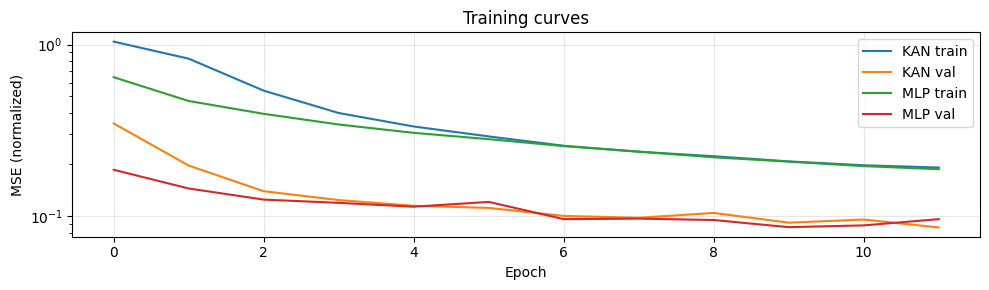

In [13]:
# Plot training curves
plt.figure(figsize=(10, 3))
plt.plot(kan_train_losses, label='KAN train')
plt.plot(kan_val_losses, label='KAN val')
plt.plot(mlp_train_losses, label='MLP train')
plt.plot(mlp_val_losses, label='MLP val')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalized)')
plt.title('Training curves')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

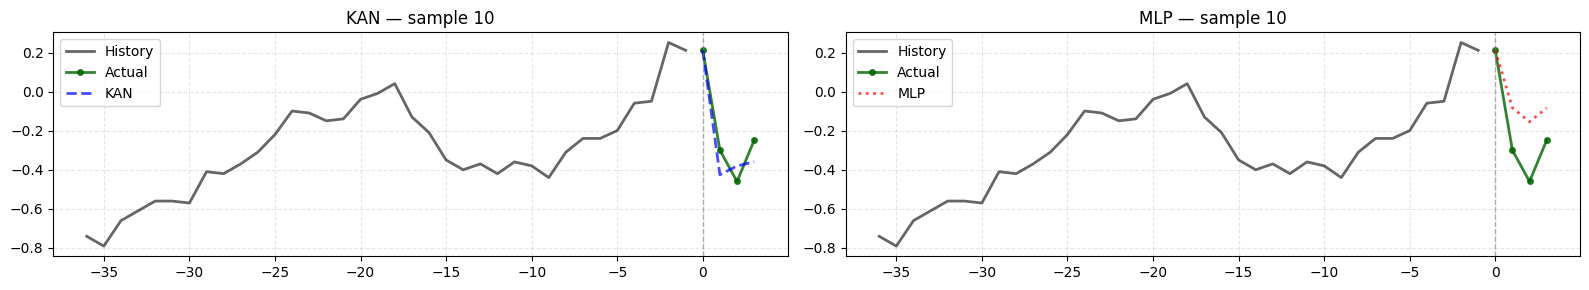

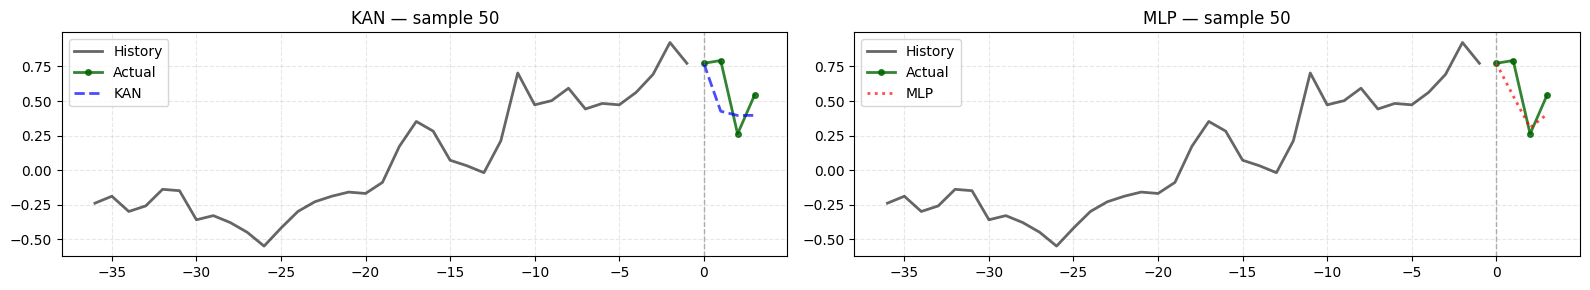

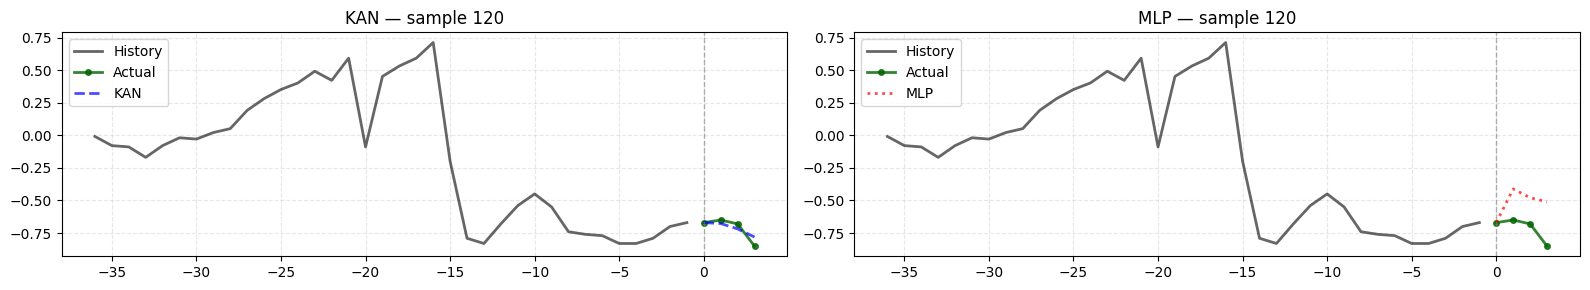

In [14]:
# Plot a few forecast examples (pm25 only)
def plot_forecast(sample_idx):
    history = X_test[sample_idx][:, target_indices[0]]
    actual = y_test[sample_idx][:TARGET_SIZE]
    pred_kan = kan_pred[sample_idx][:TARGET_SIZE]
    pred_mlp = mlp_pred[sample_idx][:TARGET_SIZE]

    history_t = np.arange(-HISTORY_SIZE, 0)
    pred_t = np.arange(0, TARGET_SIZE + 1)

    last_hist = history[-1]
    actual_c = np.concatenate([[last_hist], actual])
    kan_c = np.concatenate([[last_hist], pred_kan])
    mlp_c = np.concatenate([[last_hist], pred_mlp])

    fig, axes = plt.subplots(1, 2, figsize=(16, 3))

    axes[0].plot(history_t, history, '-', color='black', linewidth=2, alpha=0.6, label='History')
    axes[0].plot(pred_t, actual_c, 'o-', color='darkgreen', linewidth=2, markersize=4, alpha=0.8, label='Actual')
    axes[0].plot(pred_t, kan_c, '--', color='blue', linewidth=2, alpha=0.7, label='KAN')
    axes[0].axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    axes[0].set_title(f'KAN — sample {sample_idx}')
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].legend()

    axes[1].plot(history_t, history, '-', color='black', linewidth=2, alpha=0.6, label='History')
    axes[1].plot(pred_t, actual_c, 'o-', color='darkgreen', linewidth=2, markersize=4, alpha=0.8, label='Actual')
    axes[1].plot(pred_t, mlp_c, ':', color='red', linewidth=2, alpha=0.7, label='MLP')
    axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    axes[1].set_title(f'MLP — sample {sample_idx}')
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].legend()

    fig.tight_layout()
    plt.show()

for sample_idx in [10, 50, 120]:
    if sample_idx < len(X_test):
        plot_forecast(sample_idx)

In [15]:
# Save models
from pathlib import Path
Path('model_pkls').mkdir(parents=True, exist_ok=True)

kan_save_path = f"./model_pkls/pm25_kan_model.pkl"
torch.save({
    'model_state_dict': kan_model.state_dict(),
    'config': {
        'layers_hidden': KAN_LAYERS,
        'grid_min': -2.0,
        'grid_max': 2.0,
        'num_grids': 8,
        'use_base_update': False,
        'use_layernorm': False,
    }
}, kan_save_path)
print(f"KAN Model saved to {kan_save_path}")

KAN Model saved to ./model_pkls/pm25_kan_model.pkl


In [16]:
mlp_save_path = f"./model_pkls/pm25_mlp_model.pkl"
torch.save({
    'model_state_dict': mlp_model.state_dict(),
    'config': {
        'input_dim': input_dim,
        'hidden_dims': [MLP_HIDDEN_DIMS],
        'output_dim': output_dim
    }
}, mlp_save_path)
print(f"MLP Model saved to {mlp_save_path}")

MLP Model saved to ./model_pkls/pm25_mlp_model.pkl
